# Import libraries

In [1]:
import pandas as pd 

from scipy.sparse import load_npz, hstack
from sklearn.linear_model import LogisticRegression

from model_utils import train_model, classify_analysis, error_analysis
from preprocessing_utils import add_shared_features, tokens_to_text

In [2]:
PROCESS_DATA_PATH = "preprocess_data"
MODEL_PATH = "models"
RANDOM_STATE = 42

# With stopwords

## Data loading

### Data

In [3]:
train_df_sw = pd.read_parquet(f"{PROCESS_DATA_PATH}/train_df_sw_tf_idf.parquet")
val_df_sw = pd.read_parquet(f"{PROCESS_DATA_PATH}/val_df_sw_tf_idf.parquet")

train_df_sw.head(3)

,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,common_ratio,len_diff_words,len_diff_chars,question1_clean,question2_clean,tfidf_cosine
0,297402,297403,What is practical management and what is strat...,What are the practical aspects of strategic ma...,0,train,"[what, be, practical, management, and, what, b...","[what, be, the, practical, aspect, of, strateg...",5,0.555556,0.833333,1,7,what be practical management and what be strat...,what be the practical aspect of strategic mana...,0.500282
1,184949,184950,How useful is MakeUseOf Answers?,Is there any Q&A site that is not Yahoo answer...,0,train,"[how, useful, be, makeuseof, answer]","[be, there, any, q, a, site, that, be, not, ya...",2,0.117647,0.400000,11,46,how useful be makeuseof answer,be there any q a site that be not yahoo answer...,0.060493
2,101283,163744,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0,train,"[which, be, the, best, place, to, reside, in, ...","[which, ia, the, best, place, to, visit, in, i...",7,0.538462,0.777778,2,9,which be the best place to reside in india and...,which ia the best place to visit in india,0.318665


### TF-IDF

In [4]:
train_sw_q1_vec = load_npz(f"{PROCESS_DATA_PATH}/train_sw_tf_idf_q1_vec.npz")
train_sw_q2_vec = load_npz(f"{PROCESS_DATA_PATH}/train_sw_tf_idf_q2_vec.npz")

val_sw_q1_vec = load_npz(f"{PROCESS_DATA_PATH}/val_sw_tf_idf_q1_vec.npz")
val_sw_q2_vec = load_npz(f"{PROCESS_DATA_PATH}/val_sw_tf_idf_q2_vec.npz")

train_sw_q1_vec

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4671378 stored elements and shape (261296, 215129)>

## Design matrix and target

In [5]:
X_train_sw = hstack([train_sw_q1_vec, train_sw_q2_vec])
X_val_sw = hstack([val_sw_q1_vec, val_sw_q2_vec])

X_train_sw

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 9429335 stored elements and shape (261296, 430258)>

In [6]:
y_train_sw = train_df_sw['is_duplicate']
y_val_sw = val_df_sw['is_duplicate']

y_train_sw.head(3)

0    0
1    0
2    0
Name: is_duplicate, dtype: int64

## Model

In [7]:
model_sw = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
    solver='liblinear'
)

In [8]:
train_model(model_sw, X_train_sw, y_train_sw)

Training time: 8.36 seconds


(LogisticRegression(max_iter=1000, random_state=42, solver='liblinear'),
 8.360756700043567)

## Evaluation

Training
Log Loss      : 0.3451
ROC-AUC       : 0.9440
F1-score      : 0.8070
Inference time: 0.0647 s


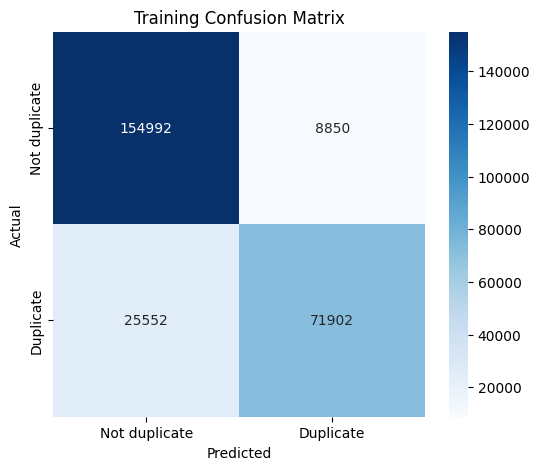


Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.95      0.90    163842
           1       0.89      0.74      0.81     97454

    accuracy                           0.87    261296
   macro avg       0.87      0.84      0.85    261296
weighted avg       0.87      0.87      0.87    261296

Validation
Log Loss      : 0.5609
ROC-AUC       : 0.7531
F1-score      : 0.5041
Inference time: 0.0166 s


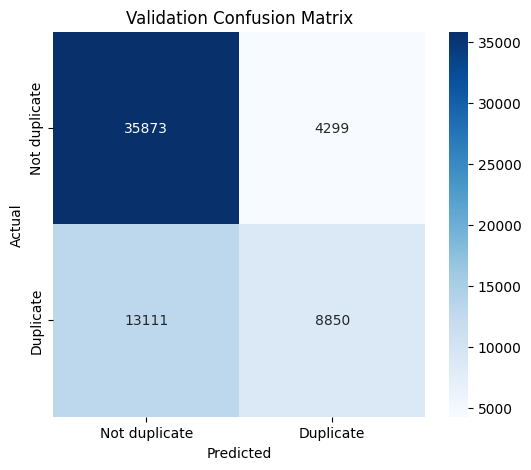


Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.89      0.80     40172
           1       0.67      0.40      0.50     21961

    accuracy                           0.72     62133
   macro avg       0.70      0.65      0.65     62133
weighted avg       0.71      0.72      0.70     62133



{'log_loss': 0.5608907279192555,
 'roc_auc': 0.7531122003897426,
 'f1_score': 0.5041298775277698,
 'inference_time': 0.016558900009840727}

In [9]:
classify_analysis(y_train_sw, X_train_sw, model_sw, 'Training')
classify_analysis(y_val_sw, X_val_sw, model_sw, 'Validation')

## Error analysis

In [10]:
train_errors_sw = error_analysis(train_df_sw, X_train_sw, model_sw)

print("False Positive training examples")
display(train_errors_sw["fp"].head())

print("False Negative training examples")
display(train_errors_sw["fn"].head())

Error Analysis
TP : 71902
TN : 154992
FP : 8850
FN : 25552
False Positive training examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,common_ratio,len_diff_words,len_diff_chars,question1_clean,question2_clean,tfidf_cosine,prediction,probability
2,101283,163744,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0,train,"[which, be, the, best, place, to, reside, in, ...","[which, ia, the, best, place, to, visit, in, i...",7,0.538462,0.777778,2,9,which be the best place to reside in india and...,which ia the best place to visit in india,0.318665,1,0.739626
20,197537,65750,How do I download free movies from torrent?,How do I download from torrent?,0,train,"[how, do, i, download, free, movie, from, torr...","[how, do, i, download, from, torrent]",6,0.750000,1.000000,2,12,how do i download free movie from torrent,how do i download from torrent,0.592177,1,0.513562
38,150637,235318,Which language do you think is the most diffic...,Which is the most difficult language of the wo...,0,train,"[which, language, do, you, think, be, the, mos...","[which, be, the, most, difficult, language, of...",7,0.466667,0.700000,2,11,which language do you think be the most diffic...,which be the most difficult language of the wo...,0.402059,1,0.635905
47,258350,258351,Why is making money online is difficult?,Is making money online real?,0,train,"[why, be, make, money, online, be, difficult]","[be, make, money, online, real]",4,0.571429,0.800000,2,12,why be make money online be difficult,be make money online real,0.464251,1,0.608727
83,72064,72065,Did India won a single medal in Rio Olympics 2...,How many medals did India won in Olympic 2016?,0,train,"[do, india, won, a, single, medal, in, rio, ol...","[how, many, medal, do, india, won, in, olympic...",6,0.461538,0.666667,1,4,do india won a single medal in rio olympics 2016,how many medal do india won in olympic 2016,0.398923,1,0.683085


False Negative training examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,common_ratio,len_diff_words,len_diff_chars,question1_clean,question2_clean,tfidf_cosine,prediction,probability
7,176809,185587,What is the best small business to start in Na...,Which business/startup should I start in Nagpu...,1,train,"[what, be, the, best, small, business, to, sta...","[which, business, startup, should, i, start, i...",5,0.263158,0.500000,5,38,what be the best small business to start in na...,which business startup should i start in nagpu...,0.318206,0,0.399910
18,153297,153298,What percent of babies in the world are born w...,What percent of babies are born with a disabil...,1,train,"[what, percent, of, baby, in, the, world, be, ...","[what, percent, of, baby, be, bear, with, a, d...",9,0.750000,1.000000,3,13,what percent of baby in the world be bear with...,what percent of baby be bear with a disability,0.827874,0,0.202488
31,114980,114981,What are the prerequisites for studying Finite...,What are the mathematical prerequisites for un...,1,train,"[what, be, the, prerequisite, for, study, fini...","[what, be, the, mathematical, prerequisite, fo...",8,0.615385,0.800000,2,5,what be the prerequisite for study finite elem...,what be the mathematical prerequisite for unde...,0.559957,0,0.204221
34,351153,351154,Now that Donald Trump is the president what ar...,What chance do Democrats have of taking back t...,1,train,"[now, that, donald, trump, be, the, president,...","[what, chance, do, democrat, have, of, take, b...",11,0.523810,0.785714,8,45,now that donald trump be the president what be...,what chance do democrat have of take back the ...,0.457745,0,0.424721
60,421632,421633,How is the master of data science program like...,What are the good universities offering data s...,1,train,"[how, be, the, master, of, data, science, prog...","[what, be, the, good, university, offer, data,...",9,0.428571,0.750000,12,63,how be the master of data science program like...,what be the good university offer data science...,0.267895,0,0.405804


In [11]:
val_errors_sw = error_analysis(val_df_sw, X_val_sw, model_sw)

print("False Positive validatiton examples")
display(val_errors_sw["fp"].head())

print("False Negative validatiton examples")
display(val_errors_sw["fn"].head())

Error Analysis
TP : 8850
TN : 35873
FP : 4299
FN : 13111
False Positive validatiton examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,common_ratio,len_diff_words,len_diff_chars,question1_clean,question2_clean,tfidf_cosine,prediction,probability
5,45508,303505,When did you join Quora?,Why did I join Quora?,0,val,"[when, do, you, join, quora]","[why, do, i, join, quora]",3,0.428571,0.600000,0,3,when do you join quora,why do i join quora,0.547603,1,0.543337
97,167896,167897,"Why does Obama always call Donald Trump ""The D...",Why is Donald Trump called 'The Donald'?,0,val,"[why, do, obama, always, call, donald, trump, ...","[why, be, donald, trump, call, the, donald]",5,0.555556,0.833333,2,13,why do obama always call donald trump the donald,why be donald trump call the donald,0.472791,1,0.594489
115,197754,197755,Why is the Knapsack problem NP complete even w...,How do you explain NP Complete and NP-hard to ...,0,val,"[why, be, the, knapsack, problem, np, complete...","[how, do, you, explain, np, complete, and, np,...",2,0.086957,0.181818,2,20,why be the knapsack problem np complete even w...,how do you explain np complete and np hard to ...,0.401391,1,0.543230
155,226839,379945,Where can I find a professional pest control s...,Where can I get best quality pest control serv...,0,val,"[where, can, i, find, a, professional, pest, c...","[where, can, i, get, best, quality, pest, cont...",8,0.571429,0.727273,0,3,where can i find a professional pest control s...,where can i get best quality pest control serv...,0.712390,1,0.555282
165,510861,510862,What's the most interesting reason you've deci...,What do you think of your Quora followers?,0,val,"[what, be, the, most, interesting, reason, you...","[what, do, you, think, of, your, quora, follower]",3,0.157895,0.375000,6,35,what be the most interesting reason you have d...,what do you think of your quora follower,0.046834,1,0.808239


False Negative validatiton examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,common_ratio,len_diff_words,len_diff_chars,question1_clean,question2_clean,tfidf_cosine,prediction,probability
1,70709,109144,How can I open a PPF account? And what are its...,What is PPF account?,1,val,"[how, can, i, open, a, ppf, account, and, what...","[what, be, ppf, account]",4,0.333333,1.000000,8,36,how can i open a ppf account and what be it be...,what be ppf account,0.559547,0,0.398849
2,6421,68425,"What is the Sahara, and how do the average tem...","What is the Sahara, and how do the average tem...",1,val,"[what, be, the, sahara, and, how, do, the, ave...","[what, be, the, sahara, and, how, do, the, ave...",14,0.823529,0.933333,1,3,what be the sahara and how do the average temp...,what be the sahara and how do the average temp...,0.753968,0,0.108232
3,26893,83712,When is it too late to learn piano?,Is it too late to learn to play the piano at 26?,1,val,"[when, be, it, too, late, to, learn, piano]","[be, it, too, late, to, learn, to, play, the, ...",7,0.583333,0.875000,4,13,when be it too late to learn piano,be it too late to learn to play the piano at 26,0.601009,0,0.403314
9,220341,22484,Which books are best for each subject while pr...,What are the best books for UGC NET commerce?,1,val,"[which, book, be, best, for, each, subject, wh...","[what, be, the, best, book, for, ugc, net, com...",7,0.500000,0.777778,4,30,which book be best for each subject while prep...,what be the best book for ugc net commerce,0.616794,0,0.469119
10,356289,356290,What is a submersible pump? What purpose does ...,What is a submersible pump?,1,val,"[what, be, a, submersible, pump, what, purpose...","[what, be, a, submersible, pump]",5,0.555556,1.000000,5,28,what be a submersible pump what purpose do it ...,what be a submersible pump,0.431921,0,0.190741


**Observation:** 
- Train Log Loss is noticeably lower than validation Log Loss (overfitting), and validation ROC-AUC (~0.75) leaves clear room for improvement

# Without stopwords

## Data Loading

### Data

In [12]:
train_df_nosw = pd.read_parquet(f"{PROCESS_DATA_PATH}/train_df_nosw_tf_idf.parquet")
val_df_nosw = pd.read_parquet(f"{PROCESS_DATA_PATH}/val_df_nosw_tf_idf.parquet")

train_df_nosw.head(3)

,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,common_ratio,len_diff_words,len_diff_chars,question1_clean,question2_clean,tfidf_cosine
0,297402,297403,What is practical management and what is strat...,What are the practical aspects of strategic ma...,0,train,"[practical, management, strategic, management]","[practical, aspect, strategic, management]",3,0.750000,1.000000,0,7,practical management strategic management,practical aspect strategic management,0.878978
1,184949,184950,How useful is MakeUseOf Answers?,Is there any Q&A site that is not Yahoo answer...,0,train,"[useful, makeuseof, answer]","[q, site, yahoo, answer, hate, speech, allow]",1,0.111111,0.333333,4,46,useful makeuseof answer,q site yahoo answer hate speech allow,0.128030
2,101283,163744,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0,train,"[best, place, reside, india]","[ia, best, place, visit, india]",3,0.500000,0.750000,1,9,best place reside india,ia best place visit india,0.225184


### TF-IDF

In [13]:
train_nosw_q1_vec = load_npz(f"{PROCESS_DATA_PATH}/train_nosw_tf_idf_q1_vec.npz")
train_nosw_q2_vec = load_npz(f"{PROCESS_DATA_PATH}/train_nosw_tf_idf_q2_vec.npz")

val_nosw_q1_vec = load_npz(f"{PROCESS_DATA_PATH}/val_nosw_tf_idf_q1_vec.npz")
val_nosw_q2_vec = load_npz(f"{PROCESS_DATA_PATH}/val_nosw_tf_idf_q2_vec.npz")

train_nosw_q1_vec

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2112912 stored elements and shape (261296, 172154)>

## Design matrix and target

In [14]:
X_train_nosw = hstack([train_nosw_q1_vec, train_nosw_q2_vec])
X_val_nosw = hstack([val_nosw_q1_vec, val_nosw_q2_vec])

X_train_nosw

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4252270 stored elements and shape (261296, 344308)>

In [15]:
y_train_nosw = train_df_nosw['is_duplicate']
y_val_nosw = val_df_nosw['is_duplicate']

y_train_nosw.head(3)

0    0
1    0
2    0
Name: is_duplicate, dtype: int64

## Model

In [16]:
model_nosw = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
    solver='liblinear'
)

In [17]:
train_model(model_nosw, X_train_nosw, y_train_nosw)

Training time: 3.99 seconds


(LogisticRegression(max_iter=1000, random_state=42, solver='liblinear'),
 3.9879864000249654)

## Evaluation

Training
Log Loss      : 0.3532
ROC-AUC       : 0.9417
F1-score      : 0.8011
Inference time: 0.0405 s


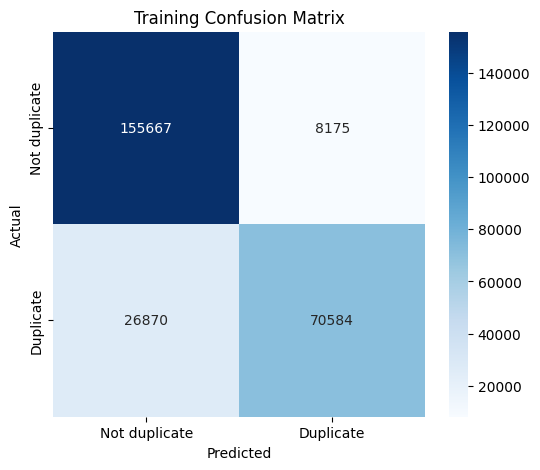


Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.95      0.90    163842
           1       0.90      0.72      0.80     97454

    accuracy                           0.87    261296
   macro avg       0.87      0.84      0.85    261296
weighted avg       0.87      0.87      0.86    261296

Validation
Log Loss      : 0.5786
ROC-AUC       : 0.7340
F1-score      : 0.4594
Inference time: 0.0113 s


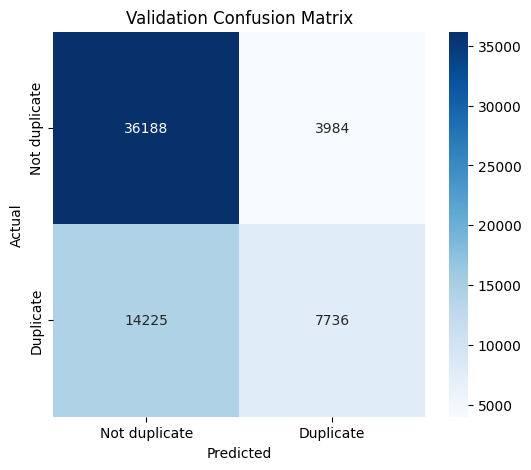


Classification Report:

              precision    recall  f1-score   support

           0       0.72      0.90      0.80     40172
           1       0.66      0.35      0.46     21961

    accuracy                           0.71     62133
   macro avg       0.69      0.63      0.63     62133
weighted avg       0.70      0.71      0.68     62133



{'log_loss': 0.5786393207728506,
 'roc_auc': 0.7339772478637836,
 'f1_score': 0.45936878358718564,
 'inference_time': 0.011337900068610907}

In [18]:
classify_analysis(y_train_nosw, X_train_nosw, model_nosw, 'Training')
classify_analysis(y_val_nosw, X_val_nosw, model_nosw, 'Validation')

## Error analysis

In [19]:
train_errors_nosw = error_analysis(train_df_nosw, X_train_nosw, model_nosw)

print("False Positive training examples")
display(train_errors_nosw["fp"].head())

print("False Negative training examples")
display(train_errors_nosw["fn"].head())

Error Analysis
TP : 70584
TN : 155667
FP : 8175
FN : 26870
False Positive training examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,common_ratio,len_diff_words,len_diff_chars,question1_clean,question2_clean,tfidf_cosine,prediction,probability
2,101283,163744,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0,train,"[best, place, reside, india]","[ia, best, place, visit, india]",3,0.500,0.750000,1,9,best place reside india,ia best place visit india,0.225184,1,0.602638
47,258350,258351,Why is making money online is difficult?,Is making money online real?,0,train,"[make, money, online, difficult]","[make, money, online, real]",3,0.600,0.750000,0,12,make money online difficult,make money online real,0.562742,1,0.737892
83,72064,72065,Did India won a single medal in Rio Olympics 2...,How many medals did India won in Olympic 2016?,0,train,"[india, single, medal, rio, olympics, 2016]","[many, medal, india, olympic, 2016]",3,0.375,0.600000,1,4,india single medal rio olympics 2016,many medal india olympic 2016,0.150594,1,0.653340
106,28858,343001,Do atheists believe in ghosts?,Do theists believe in ghosts?,0,train,"[atheist, believe, ghost]","[theist, believe, ghost]",2,0.500,0.666667,0,1,atheist believe ghost,theist believe ghost,0.630350,1,0.527602
123,48759,131997,Where is the Bermuda triangle?,What actually happens in the Bermuda Triangle?,0,train,"[bermuda, triangle]","[actually, happen, bermuda, triangle]",2,0.500,1.000000,2,16,bermuda triangle,actually happen bermuda triangle,0.663277,1,0.572039


False Negative training examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,common_ratio,len_diff_words,len_diff_chars,question1_clean,question2_clean,tfidf_cosine,prediction,probability
7,176809,185587,What is the best small business to start in Na...,Which business/startup should I start in Nagpu...,1,train,"[best, small, business, start, nagpur]","[business, startup, start, nagpur, best, chanc...",4,0.500000,0.800000,2,38,best small business start nagpur,business startup start nagpur best chance surv...,0.393637,0,0.434073
18,153297,153298,What percent of babies in the world are born w...,What percent of babies are born with a disabil...,1,train,"[percent, baby, world, bear, disability]","[percent, baby, bear, disability]",4,0.800000,1.000000,1,13,percent baby world bear disability,percent baby bear disability,0.856145,0,0.321138
31,114980,114981,What are the prerequisites for studying Finite...,What are the mathematical prerequisites for un...,1,train,"[prerequisite, study, finite, element, method,...","[mathematical, prerequisite, understand, finit...",4,0.500000,0.666667,2,5,prerequisite study finite element method finit...,mathematical prerequisite understand finite el...,0.626243,0,0.208895
60,421632,421633,How is the master of data science program like...,What are the good universities offering data s...,1,train,"[master, data, science, program, like, monash,...","[good, university, offer, data, science, maste...",5,0.357143,0.714286,7,63,master data science program like monash univer...,good university offer data science master aust...,0.264089,0,0.316864
65,31773,6887,My ex has just left me she said she doesn't lo...,How do I get my ex boyfriend back?,1,train,"[ex, leave, say, love, still, talk, get, back]","[get, ex, boyfriend, back]",3,0.333333,0.750000,4,60,ex leave say love still talk get back,get ex boyfriend back,0.143350,0,0.484279


In [20]:
val_errors_nosw = error_analysis(val_df_nosw, X_val_nosw, model_nosw)

print("False Positive training examples")
display(val_errors_nosw["fp"].head())

print("False Negative training examples")
display(val_errors_nosw["fn"].head())

Error Analysis
TP : 7736
TN : 36188
FP : 3984
FN : 14225
False Positive training examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,common_ratio,len_diff_words,len_diff_chars,question1_clean,question2_clean,tfidf_cosine,prediction,probability
5,45508,303505,When did you join Quora?,Why did I join Quora?,0,val,"[join, quora]","[join, quora]",2,1.000000,1.000000,0,3,join quora,join quora,1.000000,1,0.673980
20,346197,537204,What is the mileage of Royal Enfield Himalayan...,Which handlebar will be most comfortable for l...,0,val,"[mileage, royal, enfield, himalayan, city]","[handlebar, comfortable, long, ride, royal, en...",3,0.333333,0.600000,2,28,mileage royal enfield himalayan city,handlebar comfortable long ride royal enfield ...,0.672154,1,0.593152
43,483191,225770,What is it like to live on an Israeli settlement?,What is it like to live in an Israeli settleme...,0,val,"[like, live, israeli, settlement]","[like, live, israeli, settlement, west, bank]",4,0.666667,1.000000,2,17,like live israeli settlement,like live israeli settlement west bank,0.728837,1,0.530443
153,411616,39281,What is the meaning of 4&&5 in c programming?,What is difference between & and &&，| and || i...,0,val,"[meaning, 4, 5, c, programming]","[difference, c, programming, language]",2,0.285714,0.500000,1,26,meaning 4 5 c programming,difference c programming language,0.278961,1,0.548548
155,226839,379945,Where can I find a professional pest control s...,Where can I get best quality pest control serv...,0,val,"[find, professional, pest, control, service, a...","[get, best, quality, pest, control, service, a...",4,0.444444,0.666667,1,3,find professional pest control service australia,get best quality pest control service australia,0.717775,1,0.571426


False Negative training examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,common_ratio,len_diff_words,len_diff_chars,question1_clean,question2_clean,tfidf_cosine,prediction,probability
1,70709,109144,How can I open a PPF account? And what are its...,What is PPF account?,1,val,"[open, ppf, account, benefit]","[ppf, account]",2,0.500000,1.000000,2,36,open ppf account benefit,ppf account,0.642243,0,0.336819
2,6421,68425,"What is the Sahara, and how do the average tem...","What is the Sahara, and how do the average tem...",1,val,"[sahara, average, temperatures, compare, one, ...","[sahara, average, temperatures, compare, one, ...",5,0.625000,0.833333,1,3,sahara average temperatures compare one antarc...,sahara average temperatures compare one gibson...,0.527260,0,0.100768
3,26893,83712,When is it too late to learn piano?,Is it too late to learn to play the piano at 26?,1,val,"[late, learn, piano]","[late, learn, play, piano, 26]",3,0.600000,1.000000,2,13,late learn piano,late learn play piano 26,0.590149,0,0.424131
10,356289,356290,What is a submersible pump? What purpose does ...,What is a submersible pump?,1,val,"[submersible, pump, purpose, serve]","[submersible, pump]",2,0.500000,1.000000,2,28,submersible pump purpose serve,submersible pump,0.523271,0,0.291057
12,360478,202804,How do I find best online sites for watching T...,What websites do you use to watch TV shows?,1,val,"[find, best, online, site, watch, tv, show]","[websites, use, watch, tv, show]",3,0.333333,0.600000,2,11,find best online site watch tv show,websites use watch tv show,0.396028,0,0.367231


**Observation:** 
- Removing stopwords degrades all validation metrics compared to the with-stopwords run above — likely because function words like "is", "does", "how" carry question-structure signal that TF-IDF partially relies on.

# Next steps

- The model trained on the corpus without stop words shows a worse result, compared to their presence.
- The basic logistic regression models are clearly overtrained
- The model has difficulty taking into account the differences between questions that have many of the same words, for example,
    - "Which is the best place to reside in India and..." and "Which ia the best place to visit in India?"
    - "When did you join Quora?" and "Why did I join Quora?"